<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_05/05_ED_Pilas_Listas_Genericos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colas Circulares, Listas Enlazadas, Genéricos e Iteradores
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez  
#### **Curso:** Estructuras de Datos
---

## Índice de Contenido
1. Colas con Arreglos Circulares (Circular Array Queues)
2. Uso de Pilas: Paréntesis Balanceados
3. Introducción a las Listas Enlazadas (Linked Lists)
4. Implementación de una Pila con Listas Enlazadas
   - 4.1 El rol del Recolector de Basura (Garbage Collector)
5. Genéricos en Java (Generics `<T>`)
6. Iteradores en Java (`Iterable` e `Iterator`)
7. Listas Enlazadas Ordenadas (Ordered Linked Lists)
8. Análisis de Complejidad y Gráficas (Arreglos vs Listas)
9. Bibliografía
---

## 1. Colas con Arreglos Circulares (Circular Array Queues)

Como vimos en guías pasadas, implementar una Cola (Queue) estándar sobre un arreglo fijo presenta un problema: a medida que encolamos (al final) y desencolamos (del frente), los elementos "avanzan" hacia la derecha, desperdiciando el espacio vacío que queda a la izquierda.

Para solucionar esto, utilizamos un **Arreglo Circular**.

<p align="center">
  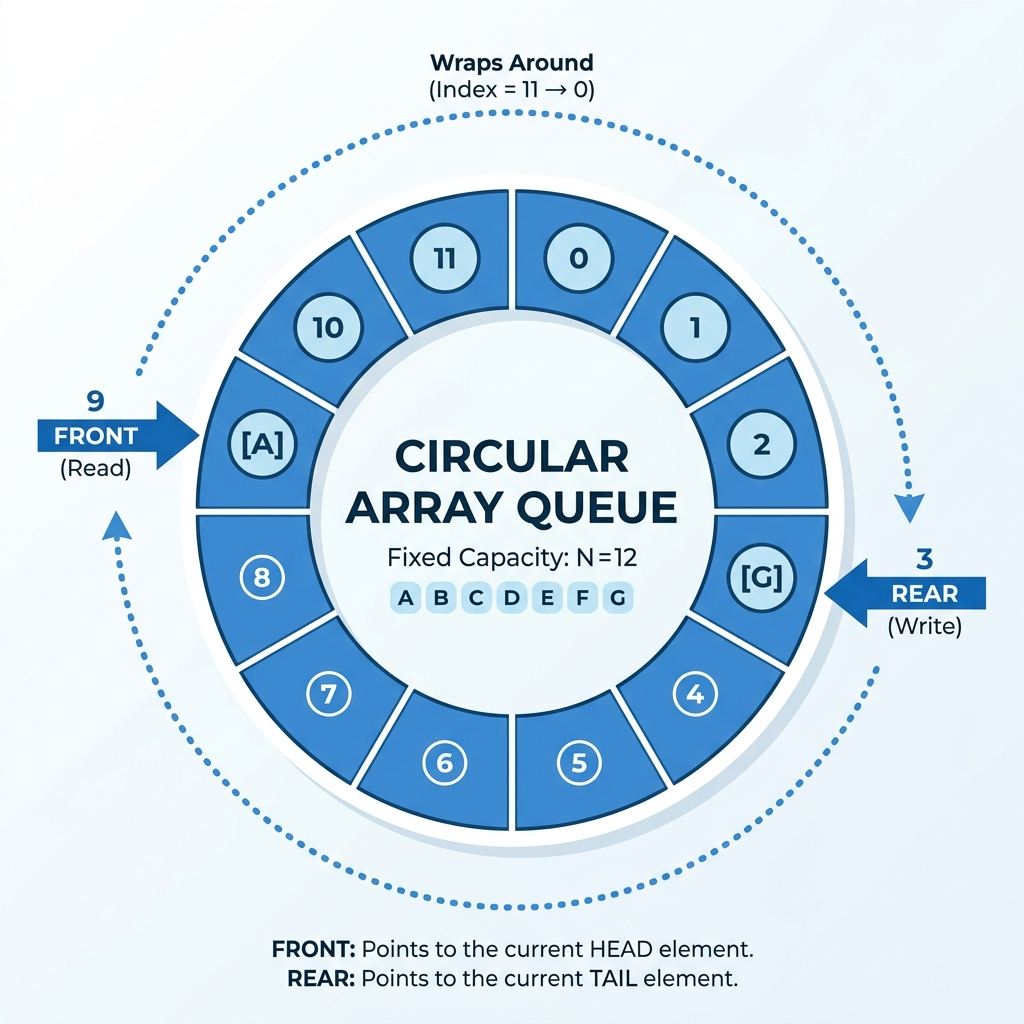<br>
  <em>Figura 1: Funcionamiento de una Cola Circular en un Arreglo usando índices envolventes.</em>
</p>

Mantenemos dos índices (`front` de lectura y `rear` de escritura). Cuando `rear` llega al límite del arreglo, da la "vuelta" y vuelve al índice `0` aprovechando los espacios liberados. Esto se logra matemáticamente usando la operación módulo (`%`).

In [1]:
%%writefile CircularQueue.java
public class CircularQueue {
    private int[] array;
    private int front, rear, size, capacity;

    public CircularQueue(int capacity) {
        this.capacity = capacity;
        this.array = new int[capacity];
        this.front = 0;
        this.size = 0;
        this.rear = capacity - 1;
    }

    public void enqueue(int key) {
        if (size == capacity) {
            System.out.println("Error: La cola circular está llena.");
            return;
        }
        // El rear da la vuelta si sobrepasa la capacidad
        rear = (rear + 1) % capacity;
        array[rear] = key;
        size++;
    }

    public int dequeue() {
        if (size == 0) {
            System.out.println("Error: La cola circular está vacía.");
            return -1;
        }
        int removedKey = array[front];
        // El front da la vuelta si sobrepasa la capacidad
        front = (front + 1) % capacity;
        size--;
        return removedKey;
    }

    public static void main(String[] args) {
        CircularQueue queue = new CircularQueue(3);
        queue.enqueue(10);
        queue.enqueue(20);
        queue.enqueue(30);
        System.out.println("Desencolado: " + queue.dequeue()); // Sale el 10

        queue.enqueue(40); // Esto daría error en una cola normal, aquí el rear pasa a 0
        System.out.println("Encolado el 40 exitosamente en la posición 0.");
    }
}


Writing CircularQueue.java


In [2]:
!javac CircularQueue.java
!java CircularQueue

[0.023s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.023s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Desencolado: 10
Encolado el 40 exitosamente en la posición 0.


> **🔗 Recurso Recomendado:** Para visualizar más ejemplos y la teoría detrás de la aritmética modular (`%`) aplicada a arreglos circulares, consulte el artículo de [GeeksforGeeks sobre Circular Queues](https://www.geeksforgeeks.org/introduction-and-array-implementation-of-circular-queue/).

## 2. Uso de Pilas: Paréntesis Balanceados

Las Pilas (Stacks) tienen una aplicación algorítmica fundamental: evaluar si una expresión tiene paréntesis o corchetes balanceados (`()`, `[]`).
**Regla:** Para estar balanceado, cada corchete que cierra debe coincidir con el último corchete que se abrió.

**Ejemplos Balanceados:** `"([])[]()"`, `"((([([])]))())"`
**Ejemplos NO Balanceados:** `"([]]()"`, `"]["`

**Práctica:**
Complete la función recorriendo el `String`. Si encuentra una apertura, empújela a la pila (`stack.push()`). Si encuentra un cierre, extraiga el tope (`stack.pop()`) y verifique si hacen pareja. Si la pila está vacía antes de tiempo, o quedan elementos al final, la cadena no está balanceada.

> **🔗 Recurso Recomendado:** Una vez termine esta implementación, le recomendamos validar su lógica intentando resolver este mismo problema directamente en el evaluador automático de [HackerRank - Balanced Brackets](https://www.hackerrank.com/challenges/balanced-brackets).

In [3]:
%%writefile BalancedBrackets.java
import java.util.Stack;

public class BalancedBrackets {

    public static boolean isBalanced(String str) {
        Stack<Character> stack = new Stack<>();

        for (int i = 0; i < str.length(); i++) {
            char c = str.charAt(i);

            // Lógica a completar por el estudiante:
            // 1. push si es '(' o '['
            // 2. si es cierre, pop y verificar coincidencia
        }

        return stack.isEmpty();
    }

    public static void main(String[] args) {
        System.out.println("([])[]()  -> " + isBalanced("([])[]()"));
        System.out.println("([]]()    -> " + isBalanced("([]]()"));
    }
}


Writing BalancedBrackets.java


In [4]:
!javac BalancedBrackets.java
!java BalancedBrackets

[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
([])[]()  -> true
([]]()    -> true


## 3. Introducción a las Listas Enlazadas (Linked Lists)

Una **Lista Enlazada (Linked List)** es una estructura de datos dinámica conformada por elementos independientes llamados **Nodos**.
A diferencia de los arreglos estáticos donde los datos están uno tras otro en la memoria, los nodos pueden estar esparcidos. Cada nodo contiene:
1. **Datos:** El valor que deseamos almacenar.
2. **Puntero `next`:** Una referencia que indica dónde se encuentra el siguiente nodo en la memoria.

La lista se recorre empezando siempre desde un nodo inicial llamado `head` (cabeza).

## 4. Implementación de una Pila con Listas Enlazadas

Al usar una Lista Enlazada para una Pila (Stack), logramos una estructura de tamaño dinámico infinito.

### Operación Push (Añadir)
<p align="center">
  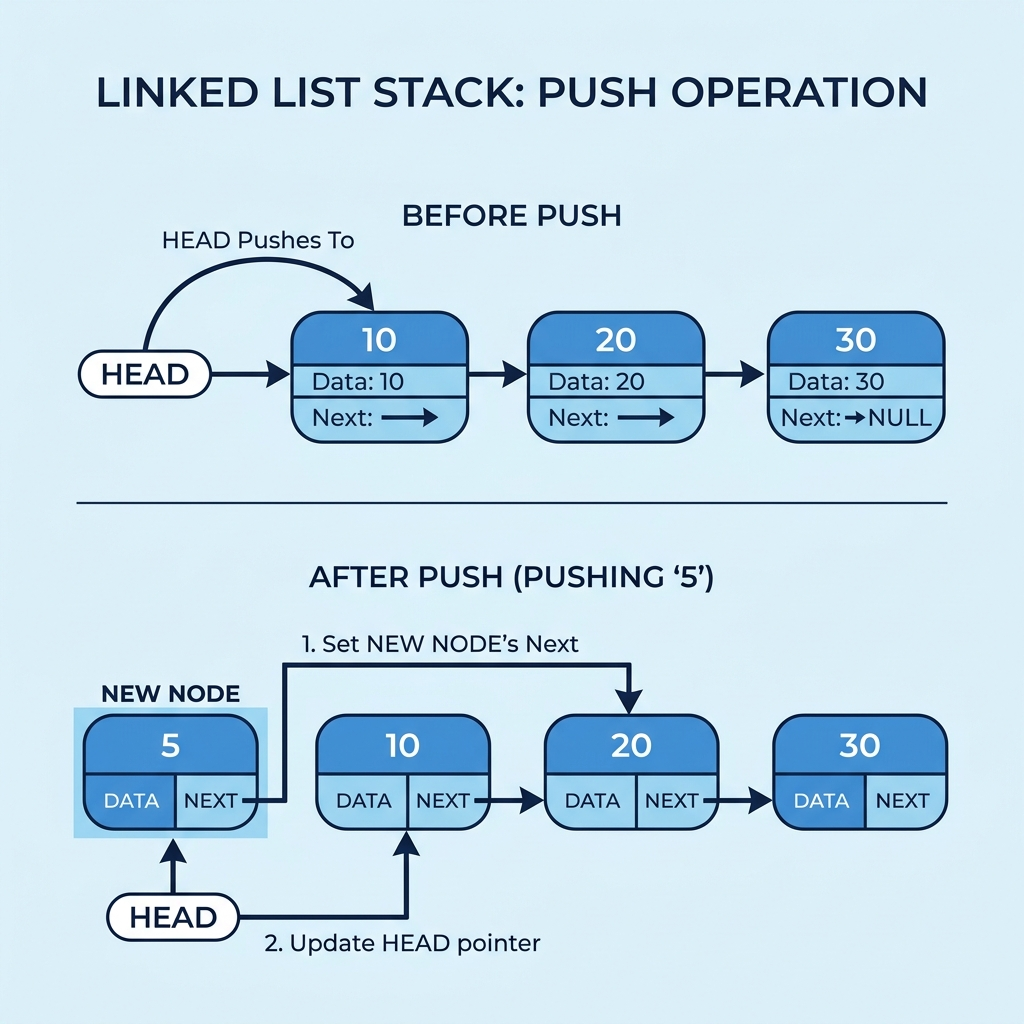<br>
</p>
Para añadir un elemento, creamos un nuevo nodo, lo apuntamos hacia el `head` actual, y luego definimos este nuevo nodo como el nuevo `head`.

### Operación Pop (Sacar)
<p align="center">
  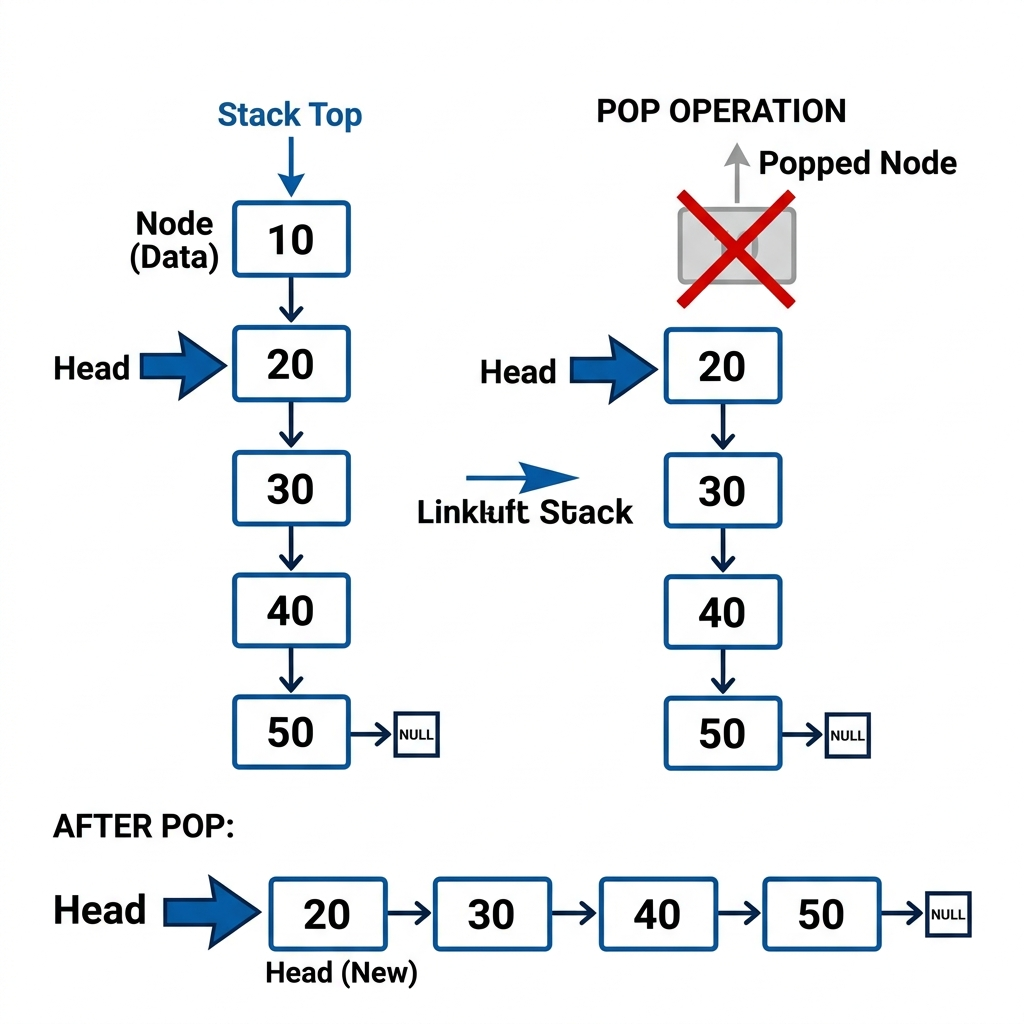<br>
</p>
Para sacar el elemento tope, simplemente actualizamos la variable `head` para que sea `head.next`. El nodo original quedará desconectado.

### 4.1 El rol del Recolector de Basura (Garbage Collector)

> **📝 Nota Teórica:** ¿Qué sucede con la memoria del nodo que desconectamos en la operación `Pop`?  
> A diferencia de lenguajes como C o C++ donde debemos liberar la memoria manualmente invocando `free()` o `delete`, Java posee un motor en segundo plano llamado **Garbage Collector (Recolector de Basura)**.  
> Cuando el Recolector de Basura detecta que un objeto en la memoria ya no tiene ninguna flecha (puntero/referencia) apuntando hacia él, asume que es "basura" y automáticamente libera ese espacio de memoria RAM por nosotros. ¡Esto es lo que hace a las listas enlazadas en Java tan seguras!

A continuación, la implementación de la **Pila Completa** en Java:

In [5]:
%%writefile LinkedStack.java
public class LinkedStack {

    private class Node {
        int data;
        Node next;
        public Node(int data) {
            this.data = data;
            this.next = null;
        }
    }

    private Node head;

    public LinkedStack() { this.head = null; }

    public void push(int data) {
        Node newNode = new Node(data);
        newNode.next = head;
        head = newNode;
    }

    public int pop() {
        if (head == null) {
            System.out.println("La pila está vacía");
            return -1;
        }
        int removedData = head.data;
        head = head.next; // El Garbage Collector destruirá el nodo anterior
        return removedData;
    }

    public static void main(String[] args) {
        LinkedStack pila = new LinkedStack();
        pila.push(50);
        pila.push(100);
        System.out.println("Pop: " + pila.pop()); // 100
        System.out.println("Pop: " + pila.pop()); // 50
    }
}


Writing LinkedStack.java


In [6]:
!javac LinkedStack.java
!java LinkedStack

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Pop: 100
Pop: 50


### 4.2 Ejemplo Práctico: Invertir una Cadena usando nuestra Pila
A continuación, utilizamos un pequeño código basado en nuestra estructura de pila para resolver un problema clásico: invertir una palabra usando `Push` y `Pop`.

In [7]:
%%writefile ReverseString.java
public class ReverseString {
    public static void main(String[] args) {
        String palabra = "Algoritmos";

        // Versión compacta de nuestra pila (adaptada para caracteres)
        class CharStack {
            class Node { char data; Node next; public Node(char d) { data = d; } }
            Node head;
            void push(char c) { Node n = new Node(c); n.next = head; head = n; }
            char pop() { char c = head.data; head = head.next; return c; }
            boolean isEmpty() { return head == null; }
        }

        CharStack pilaChars = new CharStack();
        System.out.println("Original: " + palabra);

        // 1. Llenamos la pila
        for (int i = 0; i < palabra.length(); i++) {
            pilaChars.push(palabra.charAt(i));
        }

        // 2. Vaciamos la pila (saldrá al revés por LIFO)
        System.out.print("Invertida: ");
        while (!pilaChars.isEmpty()) {
            System.out.print(pilaChars.pop());
        }
        System.out.println();
    }
}


Writing ReverseString.java


In [8]:
!javac ReverseString.java
!java ReverseString

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Original: Algoritmos
Invertida: somtiroglA


> **🔗 Recursos Recomendados para Listas Enlazadas:**
> 1. **[VisuAlgo.net (Linked List)](https://visualgo.net/en/list):** Es la mejor herramienta interactiva en línea para entender qué pasa con los punteros (`next`, `head`, `tail`) durante las inserciones y eliminaciones. ¡Muy recomendada para ver animaciones paso a paso!
> 2. **[LeetCode - Reverse Linked List](https://leetcode.com/problems/reverse-linked-list/):** Uno de los problemas más comunes en entrevistas técnicas es invertir físicamente una lista enlazada (no usar una pila externa, sino cambiar todas las flechas `next`). Puede poner a prueba sus habilidades intentando este reto en LeetCode.

## 5. Genéricos en Java (Generics `<T>`)

Si usamos un nodo tipo `int data;`, nuestra pila solo servirá para números. Para crear una estructura universal, Java ofrece los **Genéricos**.
Utilizamos un parámetro `<T>` (*Type*) para indicar que la Pila trabajará con un tipo de dato que se decidirá al momento de instanciarla.

In [9]:
%%writefile GenericStack.java
public class GenericStack<T> {

    private class Node {
        T data;
        Node next;
        public Node(T data) { this.data = data; }
    }

    private Node head;

    public void push(T data) {
        Node newNode = new Node(data);
        newNode.next = head;
        head = newNode;
    }

    public T pop() {
        if (head == null) return null;
        T removedData = head.data;
        head = head.next;
        return removedData;
    }

    public static void main(String[] args) {
        // Pila de Textos
        GenericStack<String> stringStack = new GenericStack<>();
        stringStack.push("Primer Texto");
        System.out.println("Pop de texto: " + stringStack.pop());

        // Pila de Decimales
        GenericStack<Double> doubleStack = new GenericStack<>();
        doubleStack.push(3.14);
        System.out.println("Pop de número: " + doubleStack.pop());
    }
}


Writing GenericStack.java


In [10]:
!javac GenericStack.java
!java GenericStack

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Pop de texto: Primer Texto
Pop de número: 3.14


> **🔗 Recurso Recomendado:** Para entender los Genéricos a mayor profundidad (su historia, por qué son necesarios, las reglas de compilación y los *Wildcards* como `<?>`), el artículo de **[Baeldung - The Basics of Java Generics](https://www.baeldung.com/java-generics)** es considerado uno de los más profesionales de la industria.

## 6. Iteradores en Java (`Iterable` e `Iterator`)

Cuando creamos una estructura de datos abstracta como nuestra Pila, a veces queremos recorrer sus elementos sin tener que destruirla haciéndole `pop()` a todo.

En Java, si hacemos que nuestra clase implemente la interfaz `Iterable<T>`, le estamos diciendo al compilador: *"Esta clase es capaz de devolver un objeto `Iterator` que sabe cómo recorrer los nodos uno por uno"*. Esto nos habilita a usar los elegantes ciclos `for-each` de Java (`for (T item : estructura)`).

In [11]:
%%writefile IterableStack.java
import java.util.Iterator;

public class IterableStack<T> implements Iterable<T> {

    private class Node {
        T data;
        Node next;
        public Node(T data) { this.data = data; }
    }

    private Node head;

    public void push(T data) {
        Node newNode = new Node(data);
        newNode.next = head;
        head = newNode;
    }

    // Método obligatorio de la interfaz Iterable
    @Override
    public Iterator<T> iterator() {
        return new StackIterator();
    }

    // Clase interna que sabe cómo recorrer los nodos
    private class StackIterator implements Iterator<T> {
        private Node current = head;

        @Override
        public boolean hasNext() {
            return current != null;
        }

        @Override
        public T next() {
            T data = current.data;
            current = current.next; // Avanzamos al siguiente
            return data;
        }
    }

    public static void main(String[] args) {
        IterableStack<String> stack = new IterableStack<>();
        stack.push("Java");
        stack.push("Estructuras");
        stack.push("Hola");

        System.out.println("Recorriendo la pila con un For-Each (gracias al Iterador):");
        // ¡Mágia del Iterador!
        for (String palabra : stack) {
            System.out.println("- " + palabra);
        }
    }
}


Writing IterableStack.java


In [12]:
!javac IterableStack.java
!java IterableStack

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Recorriendo la pila con un For-Each (gracias al Iterador):
- Hola
- Estructuras
- Java


## 7. Listas Enlazadas Ordenadas (Ordered Linked Lists)

<p align="center">
  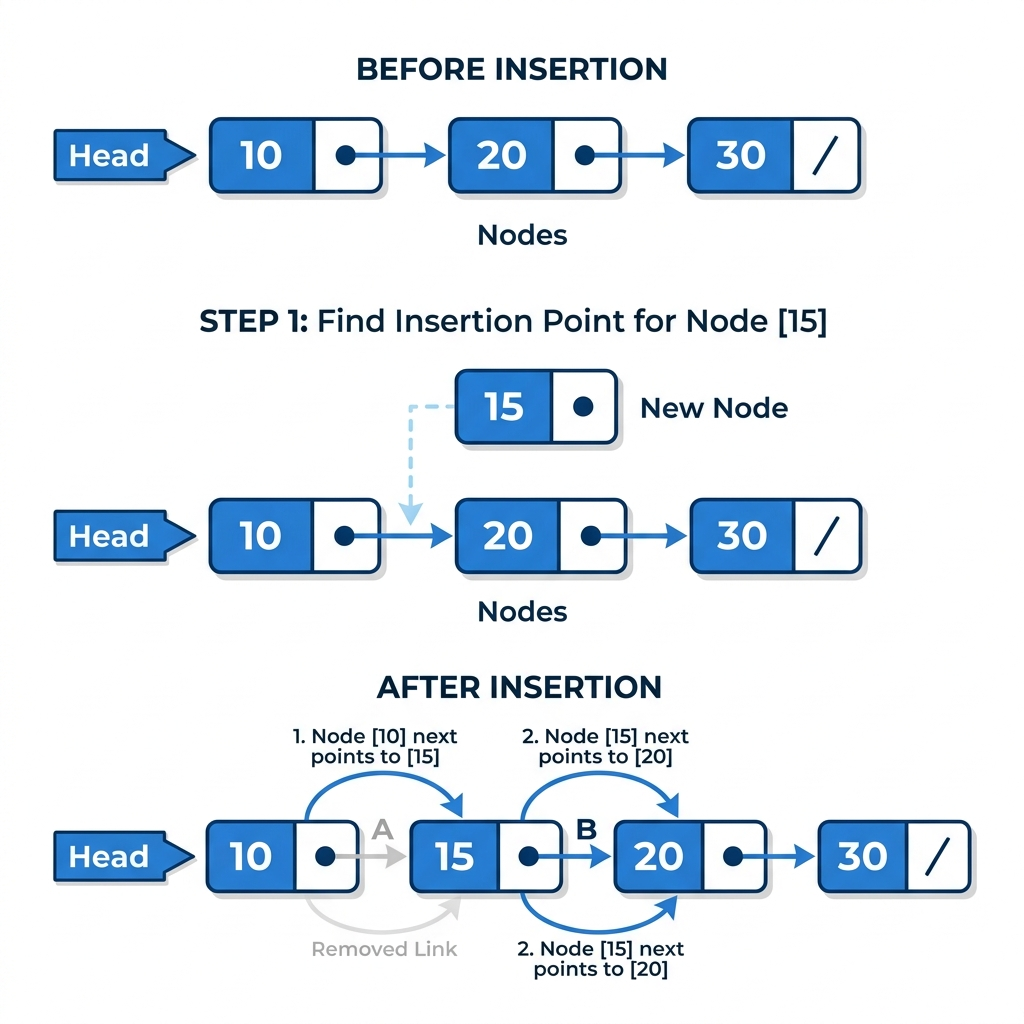<br>
  <em>Figura 4: Inserción en orden modificando los punteros previos.</em>
</p>

A veces nos interesa tener una lista que **siempre se mantenga ordenada de menor a mayor**. Para esto, al insertar un elemento, debemos recorrer la lista hasta encontrar el "hueco" correcto (usando los punteros `current` y `previous`).

In [13]:
%%writefile OrderedList.java
public class OrderedList {

    class Node {
        int data;
        Node next;
        public Node(int data) { this.data = data; }
    }

    private Node head;

    public void insertInOrder(int value) {
        Node newNode = new Node(value);
        Node current = head;
        Node previous = null;

        while (current != null && value > current.data) {
            previous = current;
            current = current.next;
        }

        if (previous == null) {
            newNode.next = head; // Inserción al inicio
            head = newNode;
        } else {
            previous.next = newNode; // Inserción al medio/final
            newNode.next = current;
        }
    }

    public void printList() {
        Node current = head;
        while (current != null) {
            System.out.print(current.data + " -> ");
            current = current.next;
        }
        System.out.println("null");
    }

    public static void main(String[] args) {
        OrderedList list = new OrderedList();
        list.insertInOrder(50);
        list.insertInOrder(10);
        list.insertInOrder(30);

        System.out.println("La lista se mantiene ordenada:");
        list.printList();
    }
}


Writing OrderedList.java


In [14]:
!javac OrderedList.java
!java OrderedList

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
La lista se mantiene ordenada:
10 -> 30 -> 50 -> null


## 8. Análisis de Complejidad y Gráficas (Arreglos vs Listas Enlazadas)

Es fundamental entender matemáticamente por qué preferimos una Lista Enlazada sobre un Arreglo para implementar estructuras dinámicas como las Pilas. Todo se resume a la Notación **Big-O**:

| Operación | Arreglo Estático | Lista Enlazada | ¿Por qué? |
| :--- | :--- | :--- | :--- |
| **Acceso a un índice arbitrario (Get)** | **$O(1)$** | $O(n)$ | El arreglo usa matemáticas de punteros para ir directo al índice. En la lista toca recorrer un nodo a la vez. |
| **Inserción al INICIO (Push)** | $O(n)$ | **$O(1)$** | En un arreglo hay que empujar *todos* los elementos una casilla a la derecha. En la lista solo toma cambiar un puntero `head`. |
| **Eliminación al INICIO (Pop)** | $O(n)$ | **$O(1)$** | En el arreglo hay que retroceder *todos* los elementos una casilla a la izquierda para tapar el hueco. |

### Visualización Gráfica

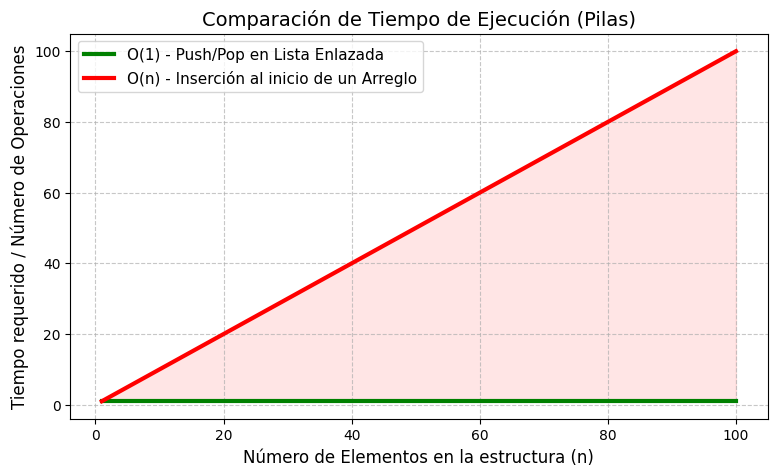

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Generamos 100 puntos simulando la cantidad de datos (n)
n = np.linspace(1, 100, 100)

# O(1) - El tiempo siempre es el mismo (Lista Enlazada)
o_1 = np.ones_like(n)

# O(n) - El tiempo crece linealmente (Arreglo)
o_n = n

plt.figure(figsize=(9, 5))
plt.plot(n, o_1, label='O(1) - Push/Pop en Lista Enlazada', color='green', linewidth=3)
plt.plot(n, o_n, label='O(n) - Inserción al inicio de un Arreglo', color='red', linewidth=3)

plt.title('Comparación de Tiempo de Ejecución (Pilas)', fontsize=14)
plt.xlabel('Número de Elementos en la estructura (n)', fontsize=12)
plt.ylabel('Tiempo requerido / Número de Operaciones', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.fill_between(n, o_1, o_n, color='red', alpha=0.1) # Área de ineficiencia
plt.show()

---
## 9. Bibliografía
- Rhodes, N. (s.f.). *Basic Data Structures: Stacks and Queues*. Department of Computer Science and Engineering, University of California, San Diego.
- Streib, J. T. (2014). *Guide to Data Structures: A Concise Introduction Using Java*. Springer. (Capítulos 2, 3, 5 y 6).